In [ ]:
import numpy as np
import pandas as pd

### No. of student and subject declaration

In [ ]:
no_of_students = 5000
# SUBJECT_CODE = {MEAN i.e difficulty of the subject,std i.e the distribution of students in the course according to there grades}
subjects ={
    'CSET243' :{'mean' : 53,'std' : 15},# Hardest subject with heaviest weight
    'CSET240' :{'mean' : 65, 'std' : 13}, # A sufficiently challenging subject
    'CSET211' :{'mean' : 70,'std': 11}, # A relatively easier subject
    'CSET201' :{'mean' : 78, 'std': 7} # A balanced difficulty subject
    }

In [ ]:
student_data = []

# Types of students -- High Achiever, Average, Struggling, Stem Specialist -- They will be used as personas while setting CGPA and RATES of student lying on this categories
for student_id in range(1, no_of_students + 1):
  persona_roll = np.random.rand()
  if persona_roll < 0.20:
    persona = "Fast learners"
    cgpa = np.random.normal(9.0,0.2)
  elif persona_roll < 0.70:
    persona = "Good"
    cgpa = np.random.normal(8.0,0.30)
  elif persona_roll < 0.85:
    persona = "Slow learners"
    cgpa = np.random.normal(5.5,0.38)
  else:
    persona = "Average"
    cgpa = np.random.normal(7.0,0.5)

# ------------------Generating SCORES Based on personas-------------------------------------
  for subject,stats in subjects.items():
    base_mean = stats['mean']

    # Adjusting mean based on persona
    if persona == "Fast learners":
      student_mean = base_mean + 20
    elif persona == "Average":
      student_mean = np.random.normal(base_mean+6, 5)
    elif persona == "Slow learners":
      student_mean = base_mean - 15
    elif persona == "Good":
      student_mean = base_mean + 12
    # elif persona == "Stem-Specialist" and subject in ['CSET211','CSET201']:
    #   student_mean = base_mean - 12
    # Generating marks with a bell-curved distribution around student means
    # Making for quiz 1, quiz 2, quiz 3, midterms
    quiz1 = np.random.normal(student_mean,stats['std'])
    quiz2 = np.random.normal(student_mean,stats['std'])
    quiz3 = np.random.normal(student_mean,stats['std'])
    midterm = np.random.normal(student_mean,stats['std']-2)



    # Adding the grades in student data[]
    student_data.append({
         'studentID' : f"E{student_id:04d}",
          'persona' : persona,
          'Current_CGPA' : round(np.clip(cgpa,1.0,10.0),2),
          'CourseID': subject,
          'Quiz_1': int(np.clip(quiz1, 20, 100)),
          'Quiz_2': int(np.clip(quiz2, 20, 100)),
          'Quiz_3': int(np.clip(quiz3, 20, 100)),
          'Midterm': int(np.clip(midterm, 20, 100))
     }
  )




In [ ]:
#Creating and saving the Data in Dataset
dataset = pd.DataFrame(student_data)

# Saving to CSV
dataset.to_csv('synthetic_grades.csv',index = False)

print("Dataset saved by the name of : 'synthetic_grades.csv'")
print("\n First 10 rows to check")
print(dataset.head(10))

Dataset saved by the name of : 'synthetic_grades.csv'

 First 10 rows to check
  studentID        persona  Current_CGPA CourseID  Quiz_1  Quiz_2  Quiz_3  \
0     E0001  Fast learners          9.07  CSET243      52      75      93   
1     E0001  Fast learners          9.07  CSET240      88      88      77   
2     E0001  Fast learners          9.07  CSET211      64      98      83   
3     E0001  Fast learners          9.07  CSET201      88      83     100   
4     E0002  Fast learners          9.39  CSET243      62      87      71   
5     E0002  Fast learners          9.39  CSET240      61     100      74   
6     E0002  Fast learners          9.39  CSET211      75     100      81   
7     E0002  Fast learners          9.39  CSET201      93      93      87   
8     E0003           Good          8.16  CSET243      60      69      61   
9     E0003           Good          8.16  CSET240      68      90      93   

   Midterm  
0       72  
1       96  
2       71  
3      100  
4       

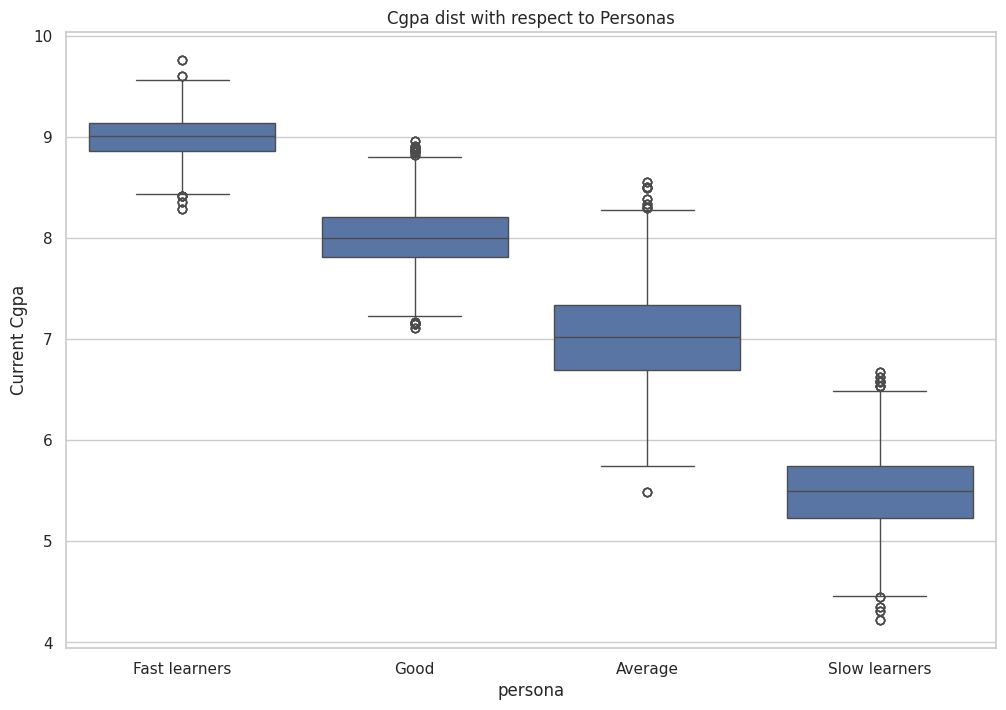

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('synthetic_grades.csv')

sns.set_theme(style="whitegrid")
# CGPA dist with respect to persona
plt.figure(figsize=(12,8))
sns.boxplot(x = 'persona', y = 'Current_CGPA', data= df, order=["Fast learners","Good","Average","Slow learners"])
plt.title('Cgpa dist with respect to Personas')
plt.xlabel('persona')
plt.ylabel('Current Cgpa')
plt.show()

/tmp/ipython-input-1913865911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CourseID', y='Midterm', data=df_stem, palette='viridis')


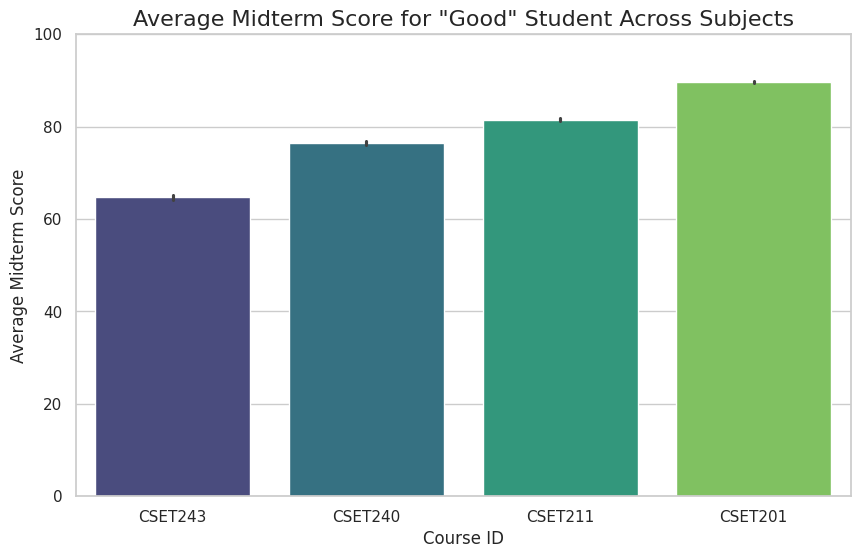

In [ ]:
plt.figure(figsize=(10, 6))
df_stem = df[df['persona'] == 'Good']
sns.barplot(x='CourseID', y='Midterm', data=df_stem, palette='viridis')
plt.title('Average Midterm Score for "Good" Student Across Subjects', fontsize=16)
plt.xlabel('Course ID', fontsize=12)
plt.ylabel('Average Midterm Score', fontsize=12)
plt.ylim(0, 100) # Set y-axis limit to 0-100 for context
plt.show()


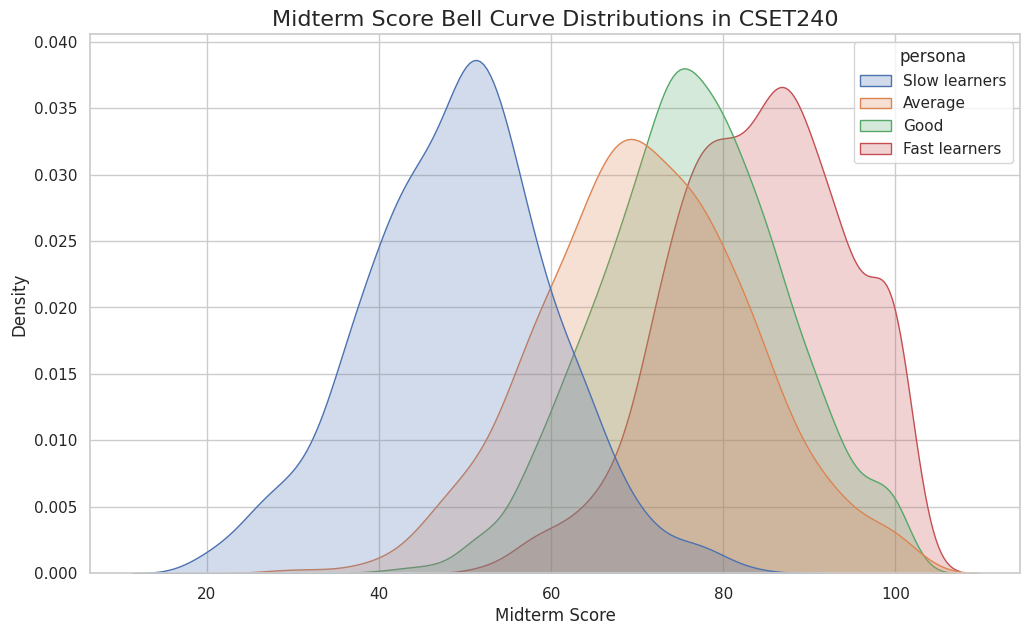

In [ ]:

df = pd.read_csv('synthetic_grades.csv')

# Set a style for the plot
sns.set_theme(style="whitegrid")

# --- Plot to Check Bell Curve Distributions ---
plt.figure(figsize=(12, 7))

# We'll check the distributions in a subject like 'CSET240'
df_subject = df[df['CourseID'] == 'CSET240']

sns.kdeplot(data=df_subject, x='Midterm', hue='persona',
            hue_order=['Slow learners', 'Average', 'Good', 'Fast learners'],
            fill=True, common_norm=False) # common_norm=False makes each curve distinct

plt.title('Midterm Score Bell Curve Distributions in CSET240', fontsize=16)
plt.xlabel('Midterm Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()